In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Problem 1. Logistic Map

### *(a)* Bifurcation diagram

In [2]:
def logistic(x,r):
    return r*x*(1-x)

def dynamical_sys(x0,f,p,warmup=1000,keep=200):
    x = x0

    for i in range(warmup):
        x = f(x,p)

    x_to_keep = np.zeros(shape=(keep,))

    for i in range(keep):
        x_to_keep[i] = f(x,p)
        x = x_to_keep[i]
    
    return x_to_keep

In [3]:
keep = 200
r_ls = np.arange(2.8,4,0.0002)
x0 = 0.25

# store results in a matrix where each row is a value of r
bifurcation_matr = np.zeros(shape=(len(r_ls), keep))

for i in range(len(r_ls)):
    bifurcation_matr[i] = dynamical_sys(x0, logistic, r_ls[i])

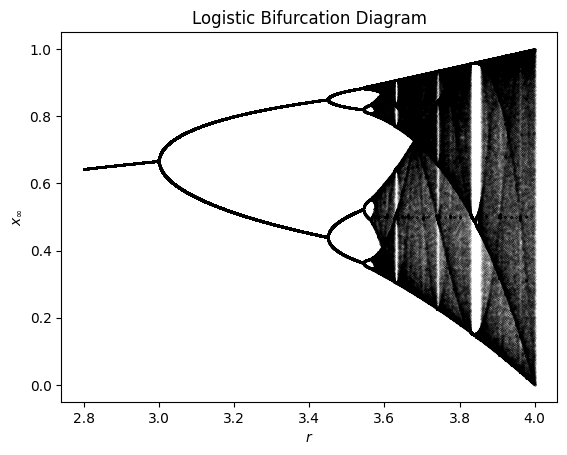

In [4]:
r_vals = np.repeat(r_ls, keep)
x_vals = bifurcation_matr.flatten()

plt.scatter(r_vals, x_vals, s=0.001, c='black')
plt.title('Logistic Bifurcation Diagram')
plt.xlabel(r'$r$')
plt.ylabel(r'$x_\infty$')
plt.show()

### *(b)* Period doubling locations

The idea for this problem is to look at the number of unique values for each $r$, and then find precisely where that changes.

In [5]:
num_unique = []
end_idx = 0
# loop through list of r's to see when the number of unique values in the long-term behavior changes.
for i in range(len(r_ls)):
    # we know the last value we care about is about 3.564 so we'll stop soon after that
    if (r_ls[i] > 3.57):
        end_idx = i
        break
    rounded = np.zeros(shape=(keep,))
    # round each endpoint to 2 decimal places to smooth over small numerical differences in similar values (i.e. 0.6657981 and 0.6657982 should not be counted as unique)
    for j in range(keep):
        rounded[j] = np.round(bifurcation_matr[i,j],4)

    # pushback the number of unique values to list
    num_unique.append(len(np.unique(rounded)))


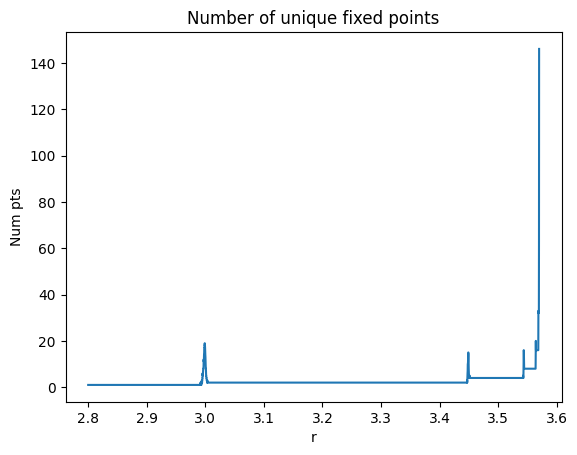

In [6]:
# plot that 
plt.plot(r_ls[:end_idx], num_unique)
plt.xlabel("r")
plt.ylabel("Num pts")

plt.title("Number of unique fixed points")
plt.show()

We see that we get little peaks around each change due to numerical instability. If we locate the centers of those peaks, those should be the values of $r$ at which period doubling occurs.

In [7]:
from scipy.signal import find_peaks
import matplotlib.pyplot as plt

num_unique = np.array(num_unique)
peaks, properties = find_peaks(num_unique)

maxima_values = r_ls[peaks]
maxima_values

array([2.9918, 2.9926, 2.994 , 2.9954, 2.9972, 2.999 , 3.0034, 3.447 ,
       3.449 , 3.4514, 3.5426, 3.5438, 3.5644, 3.5688])

So we don't get exact values, but they're pretty clearly separated so we can just take the mean of each section:

In [8]:
r1 = np.mean(maxima_values[maxima_values < 3.4])
r2 = np.mean(maxima_values[(3.4 < maxima_values) & (maxima_values < 3.5)])
r3 = np.mean(maxima_values[(3.5 < maxima_values) & (maxima_values < 3.55)])
r4 = np.mean(maxima_values[(3.55 < maxima_values) & (maxima_values < 3.57)])

In [9]:
print('r1 =',r1)
print('r2 =',r2)
print('r3 =',r3)
print('r4 =',r4)

r1 = 2.996199999999978
r2 = 3.4491333333332617
r3 = 3.543199999999918
r4 = 3.5665999999999154


Not too bad. $r_3$ and $r_4$ are a teensy bit off but for this pretty scuffed little algorithm, no complaints.

### *(c)* Feigenbaum

In [10]:
delta_2 = (r2 - r1)/(r3 - r2)
delta_3 = (r3 - r2)/(r4 - r3)

print("delta_2 =",delta_2)
print("delta_3 =",delta_3)

delta_2 = 4.815024805102764
delta_3 = 4.01994301994302


So our $\delta_2$ overshoots the known value of $\delta\approx 4.669$, while $\delta_3$ undershoots pretty substantially. I looked up the values of the actual $\delta_2$ and $\delta_3$, and our $\delta_2$ is pretty close to the actual value of $4.7514$, and the behavior should limit to the universal Feigenbaum constant from above, so $\delta_3 < \delta_2$ is technically a good sign, even though its definitely way too low (since our $r_3$ and $r_4$ are the least accurate, and having those in the denominator throws the fraction off).

### *(d)* Lyapunov exponent

In [11]:
def lyapunov(r, xs):
    N = len(xs)
    summ = 0
    for i in range(N):
        summ += np.log(np.abs(r*(1-2*xs[i])))
    return summ / N

lyapunovs = []
for i in range(len(r_ls)):
    lyapunovs.append(lyapunov(r_ls[i], bifurcation_matr[i]))

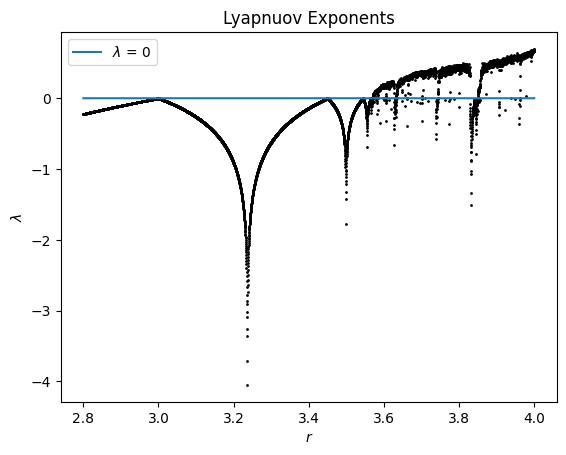

In [12]:
plt.scatter(r_ls, lyapunovs, s=1,c='black')
plt.title("Lyapnuov Exponents")
plt.ylabel(r"$\lambda$")
plt.xlabel(r"$r$")
plt.plot(r_ls, np.zeros_like(r_ls), label=r"$\lambda$ = 0")
plt.legend()
plt.show()

# Problem 2. Double Pendulum

We need to start by rearranging the equations of motion for $\ddot{\theta}_1$ and $\ddot{\theta}_2$

\begin{align*}
    2\ddot{\theta}_1 + \ddot{\theta}_2\cos(\theta_1 - \theta_2) + \dot{\theta}_2^2\sin(\theta_1 - \theta_2) + 2\frac{g}{l}\sin\theta_1 &= 0 \\
    \ddot{\theta}_2  + \ddot{\theta}_1\cos(\theta_1 - \theta_2) - \dot{\theta}_1^2\sin(\theta_1 - \theta_2) + \frac{g}{l}\sin\theta_2 &= 0
\end{align*}
If we solve both of these for $\ddot{\theta}_2$, we get:
\begin{align*}
    \ddot{\theta}_2 &= \frac{-1}{\cos(\theta_1 - \theta_2)}\left[2\ddot{\theta}_1 + \dot{\theta}_2^2\sin(\theta_1 - \theta_2) + 2\frac{g}{l}\sin\theta_1\right]\\
    \ddot{\theta}_2 &= -\left[\ddot{\theta}_1\cos(\theta_1 - \theta_2) - \dot{\theta}_1^2\sin(\theta_1 - \theta_2) + \frac{g}{l}\sin\theta_2\right]
\end{align*}
And then we can set those equal to get:
\begin{align*}
    \frac{-1}{\cos(\theta_1 - \theta_2)}\left[2\ddot{\theta}_1 + \dot{\theta}_2^2\sin(\theta_1 - \theta_2) + 2\frac{g}{l}\sin\theta_1\right]
    &=
    -\left[\ddot{\theta}_1\cos(\theta_1 - \theta_2) - \dot{\theta}_1^2\sin(\theta_1 - \theta_2) + \frac{g}{l}\sin\theta_2\right] \\
    2\ddot{\theta}_1 + \dot{\theta}_2^2\sin(\theta_1 - \theta_2) + 2\frac{g}{l}\sin\theta_1 &=
    \ddot{\theta}_1\cos^2(\theta_1 - \theta_2) - \dot{\theta}_1^2\sin(\theta_1 - \theta_2)\cos(\theta_1 - \theta_2) + \frac{g}{l}\sin\theta_2\cos(\theta_1 - \theta_2) \\
    \ddot{\theta}_1\left[2-\cos^2(\theta_1 - \theta_2)\right] &= \frac{g}{l}\left[\cos(\theta_1 - \theta_2)\sin\theta_2 - 2\sin\theta_1\right] - \sin(\theta_1 - \theta_2)
    \left[\dot\theta_1^2\cos(\theta_1-\theta_2) + \dot\theta_2^2\right] \\
    \ddot{\theta}_1 &= \frac{\frac{g}{l}\left[\cos(\theta_1 - \theta_2)\sin\theta_2 - 2\sin\theta_1\right] - \sin(\theta_1 - \theta_2)
    \left[\dot\theta_1^2\cos(\theta_1-\theta_2) + \dot\theta_2^2\right]}{1 + \sin^2(\theta_1-\theta_2)}
\end{align*}

We can then go back and rearrange the first two equations for $\ddot{\theta}_1$ and solve for $\ddot{\theta}_2$
\begin{align*}
    \ddot{\theta}_1 &= -\frac{1}{2}\left[\ddot{\theta}_2\cos(\theta_1-\theta_2) + \dot{\theta}_2^2\sin(\theta_1-\theta_2) + 2\frac{g}{l}\sin\theta_1\right] \\
    \ddot{\theta}_1 &= \frac{-1}{\cos(\theta_1 - \theta_2)}\left[\ddot{\theta}_2 - \dot{\theta}_1^2\sin(\theta_1-\theta_2) + \frac{g}{l}\sin\theta_2\right]
\end{align*}
Setting those equal,
\begin{align*}
    -\frac{1}{2}\left[\ddot{\theta}_2\cos(\theta_1-\theta_2) + \dot{\theta}_2^2\sin(\theta_1-\theta_2) + 2\frac{g}{l}\sin\theta_1\right] &= 
    \frac{-1}{\cos(\theta_1 - \theta_2)}\left[\ddot{\theta}_2 - \dot{\theta}_1^2\sin(\theta_1-\theta_2) + \frac{g}{l}\sin\theta_2\right] \\
    \ddot{\theta}_2\cos^2(\theta_1-\theta_2) + \dot{\theta}_2^2\sin(\theta_1-\theta_2)\cos(\theta_1 - \theta_2) + 2\frac{g}{l}\sin\theta_1\cos(\theta_1 - \theta_2)
    &=
    2\ddot{\theta}_2 - 2\dot{\theta}_1^2\sin(\theta_1-\theta_2) + 2\frac{g}{l}\sin\theta_2 \\
    \ddot{\theta}_2 \left[\cos^2(\theta_1-\theta_2) - 2\right] &= -\sin(\theta_1-\theta_2)\left[2\dot{\theta}_1^2 + \dot{\theta}_2^2\cos(\theta_1-\theta_2)\right] + 2\frac{g}{l}\left[\sin\theta_2 - \cos(\theta_1-\theta_2)\sin\theta_1\right]\\
    \ddot{\theta}_2 &= \frac{\sin(\theta_1-\theta_2)\left[2\dot{\theta}_1^2 + \dot{\theta}_2^2\cos(\theta_1-\theta_2)\right] + 2\frac{g}{l}\left[\cos(\theta_1-\theta_2)\sin\theta_1 - \sin\theta_2\right]}{1+\sin^2(\theta_1-\theta_2)}
\end{align*}

Now we just write this coupled system of two second order equations as a couple system of four first order equations. That is, our ODE is basically of the form $\ddot{y} = \frac{d}{dt}F(\dot{y},t)$
\begin{align*}
    \begin{bmatrix}
        \ddot{\theta}_1 \\ \ddot{\theta}_2 \\ \dot{\theta}_1 \\ \dot{\theta}_2
    \end{bmatrix} 
    &=
    \frac{d}{dt} 
    \begin{bmatrix}
        \dot{\theta}_1 \\ \dot{\theta}_2 \\ \theta_1 \\ \theta_2
    \end{bmatrix}
    \to
    \begin{bmatrix}
        \dot{x}_1 \\ \dot x_2 \\ \dot x_3 \\ \dot x_4
    \end{bmatrix}
    &=
    \begin{bmatrix}
        \ddot{\theta}_1 \text{ equation } \\
        \ddot{\theta}_2 \text{ equation } \\
        x_1 \\
        x_2
    \end{bmatrix}
\end{align*}

In [13]:
g = 9.81
l = 1

In [14]:
def dbl_pend(t,y,g=g,l=l):
    d_theta_1, d_theta_2, theta_1, theta_2 = y
    delta_theta = theta_1 - theta_2

    denom = 1 + (np.sin(delta_theta))**2

    dd_theta_1 = (
        g/l * (np.cos(delta_theta)*np.sin(theta_2) - 2*np.sin(theta_1)) 
        - np.sin(delta_theta)*(d_theta_1**2*np.cos(delta_theta) + d_theta_2**2)
        ) / denom

    dd_theta_2 = (
        2*g/l * (np.cos(delta_theta)*np.sin(theta_1) - np.sin(theta_2) 
        + np.sin(delta_theta)*(2*d_theta_1**2 + d_theta_2**2*np.cos(delta_theta)))
        ) / denom

    return [dd_theta_1, dd_theta_2, d_theta_1, d_theta_2]

### *(a)* Integrate for small-amplitude

In [15]:
from scipy.integrate import solve_ivp

In [16]:
y0 = [0,0, 0.05, 0.05*np.sqrt(2)]

sol = solve_ivp(dbl_pend, [0,20], y0, t_eval=np.linspace(0,20,1000))

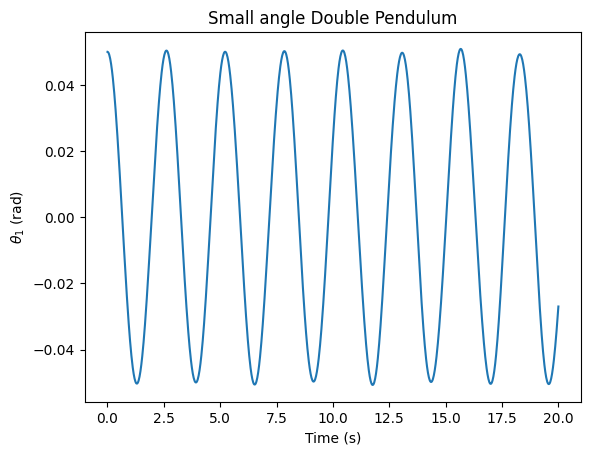

In [17]:
theta1 = sol.y[2]
plt.plot(sol.t, theta1)
plt.title("Small angle Double Pendulum")
plt.xlabel("Time (s)")
plt.ylabel(r"$\theta_1$ (rad)")
plt.show()

We can find the period by finding the time between successive peaks. By inspection, we know the first peak is roughly between 0 and 2.5, and the second is between 2.5 and 5. Since the time interval from 0 to 20 is split evenly into 1000 points, and 2.5s and 5s correspond to $\frac{1}{8}$ and $\frac{1}{4}$ of that total respectively, we'll just find the argument of max theta between idx 0 and 125, then between 125 and 250, and find the difference between the corresponding times.

In [18]:
from scipy.optimize import brentq

first_peak_idx = np.argmax(theta1[0:125])
second_peak_idx = np.argmax(theta1[125:250]) + 125   # add 125 to account for finding idx starting at 125

period = sol.t[second_peak_idx] - sol.t[first_peak_idx]

period

np.float64(2.6226226226226226)

In [19]:
true_period = 2*np.pi / (np.sqrt((2-np.sqrt(2))*(g/l)))
true_period

np.float64(2.621052430089015)

Yes, I'd say these values agree quite well.

### *(b)* Different amplitude trajectories

Since we're going to need Cartesian coordinates, it'll be good to know what those are for the bottom mass. For $l_1 = l_2 = l$, we have
\begin{align*}
    \begin{bmatrix}
        x_2 \\ y_2
    \end{bmatrix}
    =
    l
    \begin{bmatrix}
        \sin\theta_1 + \sin\theta_2                                                                                                                                                                                                                \\
        -\cos\theta_1 - \cos\theta_2
    \end{bmatrix}
\end{align*}

Cool. Next we'll solve each set of initial value problems.

In [20]:
t0 = 0
tf = 30
num_t = 500

In [21]:
small_y0 = [0.1, 0.1, 0,0]

small_sol = solve_ivp(dbl_pend, [t0,tf], small_y0, t_eval=np.linspace(t0,tf,num_t))

In [22]:
medium_y0 = [0.5, 0.5, 0,0]

medium_sol = solve_ivp(dbl_pend, [t0,tf], medium_y0, t_eval=np.linspace(t0,tf,num_t))

In [23]:
large_y0 = [np.pi/2, np.pi/2, 0,0]

large_sol = solve_ivp(dbl_pend, [t0,tf], large_y0, t_eval=np.linspace(t0,tf,num_t))

In [24]:
def cartesian_traj(sol_vec, l=l):
    theta_1 = sol_vec[2]
    theta_2 = sol_vec[3]

    return [l*(np.sin(theta_1) + np.sin(theta_2)), -l*(np.cos(theta_1)+np.cos(theta_2))]

sm_x2, sm_y2 = cartesian_traj(small_sol.y)
md_x2, md_y2 = cartesian_traj(medium_sol.y)
lg_x2, lg_y2 = cartesian_traj(large_sol.y)

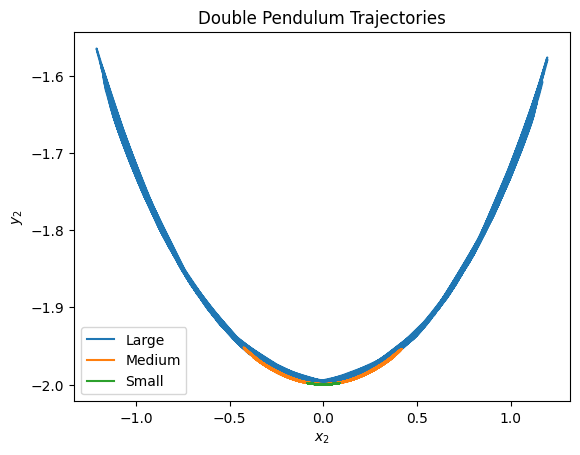

In [25]:
plt.plot(lg_x2,lg_y2,label="Large")
plt.plot(md_x2,md_y2,label="Medium")
plt.plot(sm_x2,sm_y2,label="Small")

plt.legend()
plt.title("Double Pendulum Trajectories")
plt.xlabel(r"$x_2$")
plt.ylabel(r"$y_2$")


plt.show()

As we might expect, the larger the initial amplitude, we sweep out a larger and larger oscillation. For small amplitudes, the lower mass stays pretty close to the equilibrium position. A bit larger amplitude, we sweep out more, and then for the large one we sweep the whole range.

### *(c)* Sensitivity to initial conditions

In [26]:
t0 = 0
tf = 100
num_t = 2000

In [27]:
y0_a = [np.pi/2, np.pi/2, 0,0]
sol_a = solve_ivp(dbl_pend, [t0,tf], y0_a, t_eval=np.linspace(t0,tf,num_t))

y0_b = [np.pi/2+1e-9, np.pi/2, 0,0]
sol_b = solve_ivp(dbl_pend, [t0,tf], y0_b, t_eval=np.linspace(t0,tf,num_t))

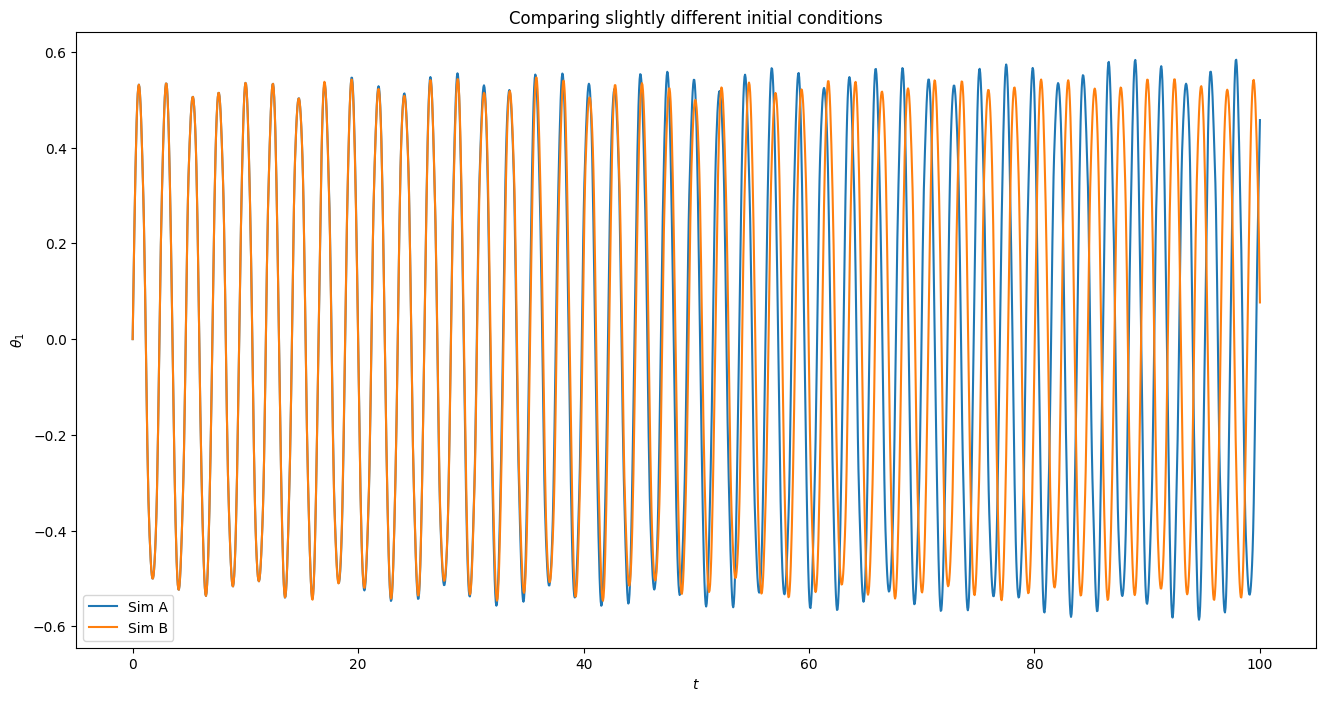

In [28]:
plt.figure(figsize=(16,8))
plt.plot(sol_a.t, sol_a.y[2],label='Sim A')
plt.plot(sol_b.t, sol_b.y[2],label='Sim B')

plt.legend()
plt.title("Comparing slightly different initial conditions")
plt.ylabel(r"$\theta_1$")
plt.xlabel(r"$t$")


plt.show()


Significant divergence starts to occur around $t = 50$ seconds 

### *(d)* Lyapunov grind

In [29]:
theta1_a = sol_a.y[2]
theta2_a = sol_a.y[3]

theta1_b = sol_b.y[2]
theta2_b = sol_b.y[3]

Delta = np.sqrt((theta1_a - theta1_b)**2 + (theta2_a - theta2_b)**2)

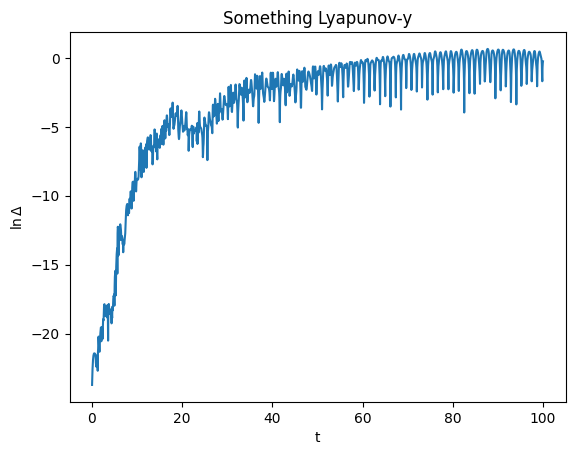

In [30]:
plt.plot(sol_a.t[1:], np.log(Delta[1:]))
plt.title("Something Lyapunov-y")
plt.xlabel("t")
plt.ylabel(r"$\ln\Delta$")
plt.show()

We can find the Lyapunov exponent as the slope of the linear-ish region. So we'll take that $\ln\Delta$ up to like $t=15$ and then do a linear regression about it.

In [31]:
end_idx = int(num_t*0.15)
fit_data = np.log(Delta[1:end_idx])

In [32]:
from scipy.stats import linregress

lyap = linregress(sol_a.t[1:end_idx], fit_data)
lyap[0]

np.float64(1.263446928127252)

In [33]:
t_pred = 1/lyap[0]
t_pred

np.float64(0.7914855604439618)

This means we can only predict this chaotic system up to about 0.8 seconds.

### *(e)* Conceptual

The cross terms with both $\theta_1$ and $\theta_2$ are what cause the chaotic behavior for larger displacements. They are basically independent for small displacements, but the cross terms at large amplitudes go crazy.

# Problem 3a. Triatomic Molecule

\begin{align*}
    m\ddot{x}_1 &= -k(x_1 - x_2) \\
    M\ddot{x}_2 &= -k(x_2 - x_1) - k(x_2 - x_3) \\
    m\ddot{x}_3 &= -k(x_3 - x_2)
\end{align*}

### *(a)* Constructing stuff

(i) Mass and stiffness matrix
\begin{align*}
    \begin{bmatrix}
        m & 0 & 0 \\
        0 & M & 0 \\
        0 & 0 & m
    \end{bmatrix}
    \begin{bmatrix}
        \ddot{x}_1 \\ \ddot{x}_2 \\ \ddot{x}_3
    \end{bmatrix}
    &= 
    -
    \begin{bmatrix}
        k & -k & 0  \\
        -k & 2k & -k \\
        0 & -k & k
    \end{bmatrix}
    \begin{bmatrix}
        x_1 \\ x_2 \\ x_3
    \end{bmatrix}
\end{align*}

In [34]:
m = 10
M = 5

k = 2

M_matr = np.array([[m,0,0], [0,M,0], [0,0,m]])
K_matr = -k*np.array([[1,-1,0], [-1,2,-1], [0,-1,1]])

(ii) Eigenvalues

Letting $\vec{x} = \vec{A}\cos(\omega t + \phi)$, such that $\ddot{\vec{x}} = -\omega^2\vec{x}$

\begin{align*}
    \mathsf{M}\ddot{\vec{x}} &= -\mathsf{K} \vec{x} \\
    \omega^2\mathsf{M}\vec{A} &= \mathsf{K} \vec{A}
\end{align*}

In [35]:
from scipy.linalg import eigh

eigval, eigvec = eigh(K_matr, M_matr)

(iii) Normal modes

In [36]:
omegas = np.sqrt(np.abs(eigval))
omegas

array([1.00000000e+00, 4.47213595e-01, 5.79067613e-09])

In [37]:
eigvec

array([[ 1.00000000e-01, -2.23606798e-01, -2.00000000e-01],
       [-4.00000000e-01,  1.23811542e-16, -2.00000000e-01],
       [ 1.00000000e-01,  2.23606798e-01, -2.00000000e-01]])

(iv) Describe motion in each mode

First mode is the antisymmetric the outer two move together

Second mode is the middle atom stays still the others move opposite directions

Last mode is symmetric they all go together yay



### *(b)* Specific modes

To solve this system we'll again need to translate the second order into coupled first order. First let $\begin{bmatrix}
        x \\ \dot{x}
    \end{bmatrix} = \begin{bmatrix}
        x_0 \\ x_1
    \end{bmatrix}$

\begin{align*}
    \frac{d}{dt} \begin{bmatrix}
        x_0 \\ x_1
    \end{bmatrix}
    =
    \begin{bmatrix}
        x_1 \\ \mathsf{M}^{-1}\mathsf{K}x_0
    \end{bmatrix}
\end{align*}

In [38]:
def triatomic(t,y):
    x1,x2,x3, dx1,dx2,dx3 = y

    x = np.array([x1,x2,x3])
    dx = np.array([dx1,dx2,dx3])

    ddx = np.linalg.inv(M_matr) @ K_matr @ x

    return np.concatenate((dx, ddx))

In [39]:
t0 = 0
tf = 60
num_t = 500

tri_y0 = np.array([1,0,0,0,0,0])

tri_sol = solve_ivp(triatomic, [t0,tf], tri_y0, t_eval=np.linspace(t0,tf,num_t))

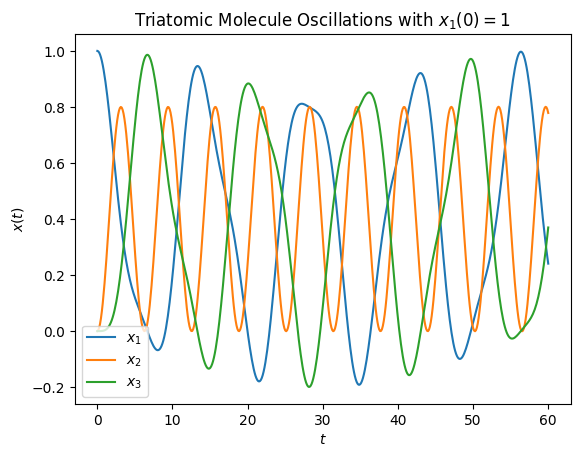

In [40]:
plt.plot(tri_sol.t, tri_sol.y[0], label=r'$x_1$')
plt.plot(tri_sol.t, tri_sol.y[1], label=r'$x_2$')
plt.plot(tri_sol.t, tri_sol.y[2], label=r'$x_3$')

plt.legend()

plt.title("Triatomic Molecule Oscillations with " + r"$x_1(0)=1$")
plt.xlabel(r"$t$")
plt.ylabel(r"$x(t)$")
plt.show()

This looks like a superposition of normal modes I think. The beat frequency would be the difference in the frequencies of $x_1$ and $x_3$.

# Problem 3b. Chain of Oscillators

### *(c)* Dispersion

(i) The general form of the equations of motion is:
\begin{align*}
    m\ddot{x}_i &= - k(x_i - x_{i-1}) + k(x_{i+1} - x_{i}) \\
    &= -k \left( - x_{i-1} + 2x_i - x_{i+1}\right)
\end{align*}

So the stiffness matrix will have 2s along the diagonal, then -1 directly to the left and right of the diagonal

In [41]:
def stiffness_matrix(N, k=1):
    K = 2*np.identity(N)

    for i in range(N):
        if(i != 0):
            K[i-1, i] = -1
        if(i != N-1):
            K[i+1, i] = -1

    return k*K

(ii) Normal mode frequencies

Since all masses are equal, the mass matrix is just $m$ times the identity, so the eigenvalues of $\mathsf{K}$ are just the squared frequncies, so $\omega_i = \sqrt{\lambda_i}$

In [42]:
def normal_modes(K):
    eigval, eigvec = eigh(K)
    return np.sqrt(np.abs(eigval))

In [43]:
K_10 = stiffness_matrix(10)
omega_10 = normal_modes(K_10)

K_50 = stiffness_matrix(50)
omega_50 = normal_modes(K_50)

K_100 = stiffness_matrix(100)
omega_100 = normal_modes(K_100)

(iii) Plotting dispersion relation

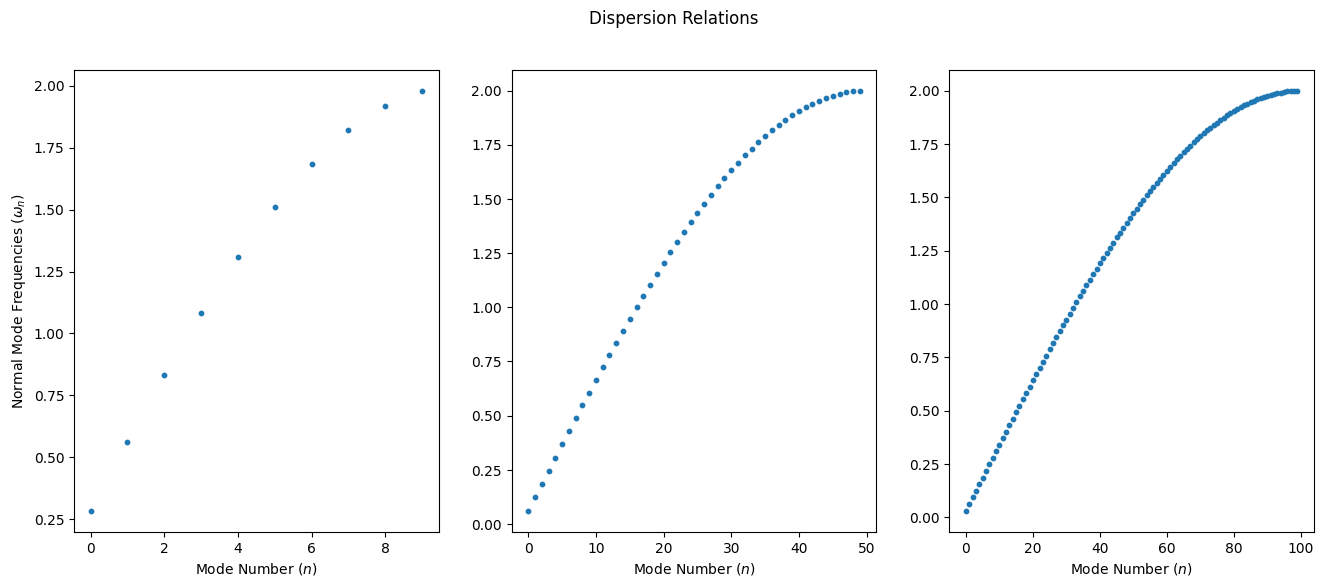

In [44]:
fig,ax = plt.subplots(nrows=1,ncols=3, figsize=(16,6))
ax[0].scatter(np.linspace(0,9,10), omega_10, s=10)
ax[1].scatter(np.linspace(0,49,50), omega_50, s=10)
ax[2].scatter(np.linspace(0,99,100), omega_100, s=10)

fig.suptitle("Dispersion Relations")

ax[0].set_ylabel("Normal Mode Frequencies " + r"($\omega_n$)")

ax[0].set_xlabel(r"Mode Number ($n$)")
ax[1].set_xlabel(r"Mode Number ($n$)")
ax[2].set_xlabel(r"Mode Number ($n$)");

Now let's compare these to the analytical result. We'll compute the analytical for each and then do mean percent differece between them for each $N$.

In [45]:
def analytical_normal_modes(N):
    omega = np.zeros(N)
    for n in range(N):
        omega[n] = 2 * np.sin( ((n+1)*np.pi) / (2*(N+1)) ) # need to use n+1 since equation starts at n=1
    return omega

In [46]:
analytical_omega_10 = analytical_normal_modes(10)
analytical_omega_50 = analytical_normal_modes(50)
analytical_omega_100 = analytical_normal_modes(100)

In [47]:
def mean_pct_difference(a,b):
    return (2*(a-b) / (a+b)).mean()

In [48]:
pct_10 = mean_pct_difference(omega_10, analytical_omega_10)
pct_50 = mean_pct_difference(omega_50, analytical_omega_50)
pct_100 = mean_pct_difference(omega_100, analytical_omega_100)

print("N=10 mean percent difference: ", pct_10)
print("N=50 mean percent difference:", pct_50)
print("N=100 mean percent difference:", pct_100)

N=10 mean percent difference:  2.514476039334802e-15
N=50 mean percent difference: -7.167190891042598e-15
N=100 mean percent difference: 5.5625227423214e-15


These are all basically zero, so they agree very well.

### *(d)* Visualizing modes

In [49]:
np.repeat(2,5)

array([2, 2, 2, 2, 2])

NameError: name 'ply' is not defined

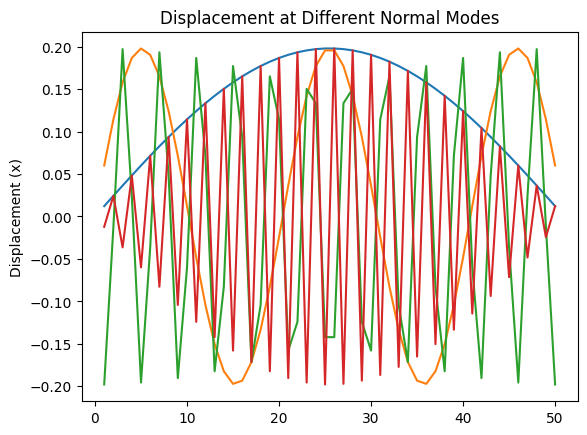

In [50]:
eigval, eigvec = eigh(K_50)

modes = [0, 4, 24, 49]

for m in modes:
    plt.plot(np.arange(1, 51), eigvec[:, m], label=f"n={m+1}")

plt.title("Displacement at Different Normal Modes")
plt.ylabel("Displacement (x)")
ply.xlabel("Chain index (n)")
plt.legend()
plt.show()

Wavelength decreases as $n$ increases, which makes sense as a higher frequency should correspond to a smaller wavelength as per standing waves.

### *(e)* Conceptual

(i) As $N$ increases, the normal mode frequencies get infinitesimally close together.

(ii) The highest possible value for the frequency is 2, since the shortest frequency mode fills the entire space of half a wavelength, and frequency is inversely proportional to wavelength

# Problem 4. Tumbling Rigid Body

### *(a)* Rotation about principal axes

In [ ]:
I_1 = 1
I_2 = 2
I_3 = 3

def rigid_body(t, y, I_1=I_1, I_2=I_2, I_3=I_3):
    omega_1, omega_2, omega_3 = y

    d_omega_1 = (I_2 - I_3) / I_1 * omega_2 * omega_3
    d_omega_2 = (I_3 - I_1) / I_2 * omega_3 * omega_1
    d_omega_3 = (I_1 - I_2) / I_3 * omega_1 * omega_2

    return [d_omega_1, d_omega_2, d_omega_3]

In [ ]:
t0 = 0
tf = 50
num_t = 5000

ax1_y0 = [1, 0.01, 0.01]
ax2_y0 = [0.01, 1, 0.01]
ax3_y0 = [0.01, 0.01, 1]

ax1_sol = solve_ivp(rigid_body, [t0,tf], ax1_y0, t_eval = np.linspace(t0,tf,num_t), rtol=1e-10, atol=1e-12)
ax2_sol = solve_ivp(rigid_body, [t0,tf], ax2_y0, t_eval = np.linspace(t0,tf,num_t), rtol=1e-10, atol=1e-12)
ax3_sol = solve_ivp(rigid_body, [t0,tf], ax3_y0, t_eval = np.linspace(t0,tf,num_t), rtol=1e-10, atol=1e-12)

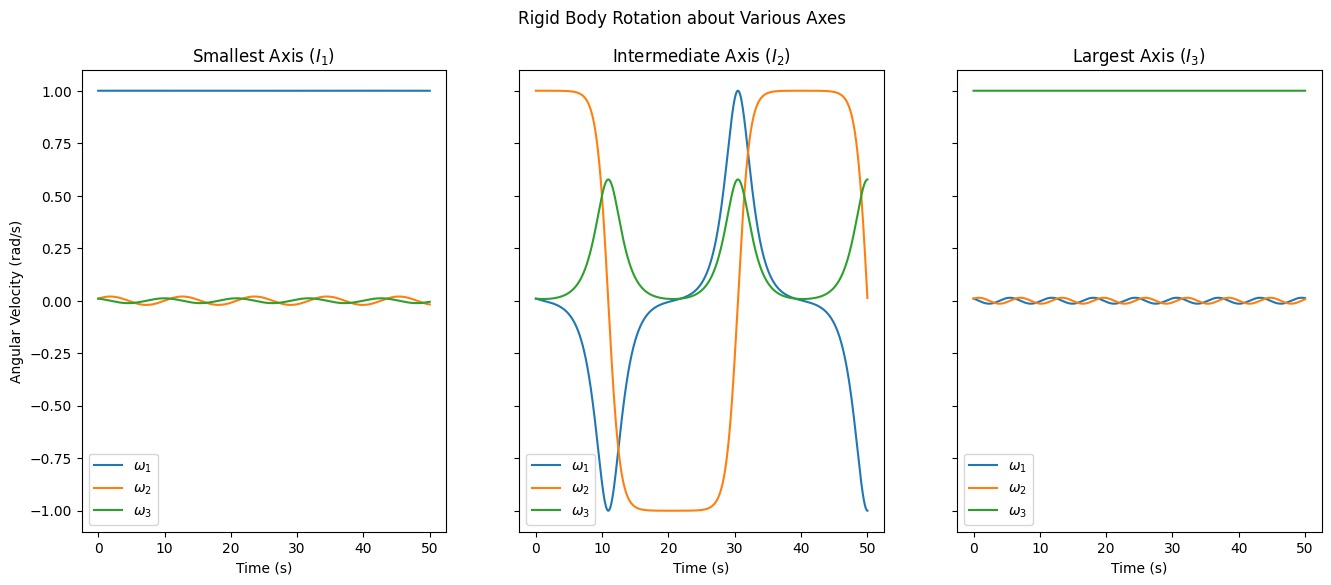

In [ ]:
fig,axs = plt.subplots(1,3, figsize=(16,6), sharey=True)

fig.suptitle(r"Rigid Body Rotation about Various Axes")

axs[0].plot(ax1_sol.t, ax1_sol.y[0], label=r"$\omega_1$")
axs[0].plot(ax1_sol.t, ax1_sol.y[1], label=r"$\omega_2$")
axs[0].plot(ax1_sol.t, ax1_sol.y[2], label=r"$\omega_3$")

axs[0].set_title(r"Smallest Axis ($I_1$)")
axs[0].set_xlabel(r"Time (s)")
axs[0].set_ylabel(r"Angular Velocity (rad/s)")
axs[0].legend()


axs[1].plot(ax2_sol.t, ax2_sol.y[0], label=r"$\omega_1$")
axs[1].plot(ax2_sol.t, ax2_sol.y[1], label=r"$\omega_2$")
axs[1].plot(ax2_sol.t, ax2_sol.y[2], label=r"$\omega_3$")

axs[1].set_title(r"Intermediate Axis ($I_2$)")
axs[1].set_xlabel(r"Time (s)")
axs[1].legend()


axs[2].plot(ax3_sol.t, ax3_sol.y[0], label=r"$\omega_1$")
axs[2].plot(ax3_sol.t, ax3_sol.y[1], label=r"$\omega_2$")
axs[2].plot(ax3_sol.t, ax3_sol.y[2], label=r"$\omega_3$")

axs[2].set_title(r"Largest Axis ($I_3$)")
axs[2].set_xlabel(r"Time (s)")
axs[2].legend()


plt.show()

### *(b)* Stability Classification

Rotation about the largest and smallest axes is stable, as the small perturbations around the other axes just oscillate, staying close to their initial values. In the unstable case, about the intermediate axis, the angular velocity components change pretty wildly. The angular velocity flips back and forth due to the instability, and rotation about the other axes is rather strong, with one axis changing in sign throughout the rotation as well, and the other just changing in magnitude.

### *(c)* Conservation

In [ ]:
def L_and_T(sol_y, I_1=I_1, I_2=I_2, I_3=I_3):
    om1, om2, om3 = sol_y

    L = np.sqrt((I_1*om1)**2 + (I_2*om2)**2 + (I_3*om3)**2)
    T = (I_1*om1**2 + I_2*om2**2 + I_3*om3**2) / 2

    return [L,T]

In [ ]:
L, T = L_and_T(ax2_sol.y)

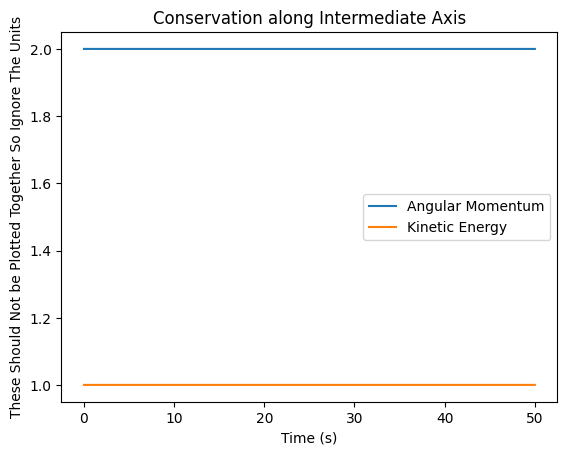

In [ ]:
plt.plot(ax2_sol.t, L, label="Angular Momentum")
plt.plot(ax2_sol.t, T, label="Kinetic Energy")
plt.title("Conservation along Intermediate Axis")
plt.xlabel("Time (s)")
plt.ylabel(r"These Should Not be Plotted Together So Ignore The Units")
plt.legend()
plt.show()

Looks pretty constant to me.

### *(d)* Phase Space Trajectory

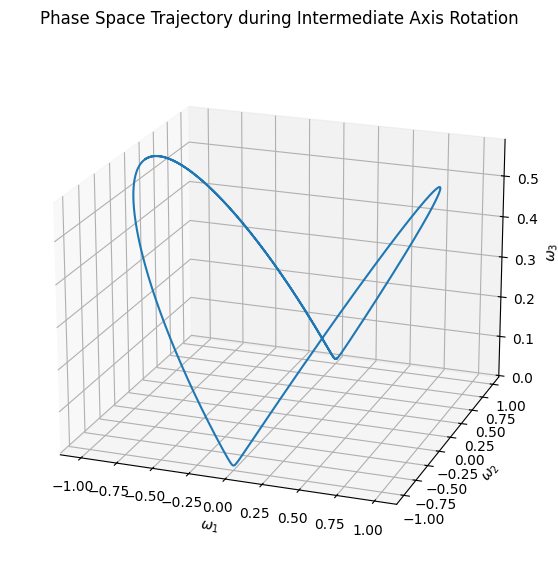

In [ ]:
ax = plt.figure(figsize = (7,7)).add_subplot(projection='3d')
ax.plot(ax2_sol.y[0],ax2_sol.y[1],ax2_sol.y[2])

ax.set_title("Phase Space Trajectory during Intermediate Axis Rotation")
ax.set_xlabel(r'$\omega_1$')
ax.set_ylabel(r'$\omega_2$')
ax.set_zlabel(r'$\omega_3$')

ax.view_init(elev=20, azim=-70, roll=0)


Not entirely sure what we're supposed to call this shape. Pringle, or perhaps butterfly. Either way, since energy is conserved, we get a closed loop phase space trajectory. Thank you Hamilton.

### *(e)* Conceptual

Rotation about the intermediate axis is necessarily unstable due to the coefficients in the Euler equations. Rotation about the stable axes gives oscillatory solutions to the other axes, but for the intermediate axis there's an exponential solution to the ODEs. Physically, since the other axes have more energy (due to exponential solutions), conservation of energy dictates that the intermediate axis needs to lose energy.